# 🦟 Dengue Risk Prediction - Data Preprocessing

## 📋 Objective
This notebook performs comprehensive data preprocessing for the Dengue Risk Prediction project.

### Steps Covered:
1. **Data Loading** - Load the dengue dataset
2. **Initial Exploration** - Understand data structure and statistics
3. **Missing Value Analysis** - Identify and handle null values
4. **Data Cleaning** - Remove duplicates, handle outliers
5. **Feature Engineering** - Create new features if needed
6. **Encoding** - Convert categorical variables
7. **Scaling** - Normalize numerical features
8. **Train-Test Split** - Prepare data for modeling
9. **Save Processed Data** - Export cleaned dataset

## 1️⃣ Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2️⃣ Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('dengue_india_weekly_with_nulls.csv')

print(f"📊 Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Display first few rows
df.head(10)

📊 Dataset loaded successfully!
Shape: 15600 rows × 15 columns



,Year,Month,Week,Season,City,Average Temperature (°C),Average Rainfall (mm),Average Humidity (%),Air Quality Index (AQI),Mosquito Density Index,Population Density (people per sq km),Dengue Cases Reported,Outbreak Risk Level,Latitude,Longitude
0,2015.0,January,1.0,Winter,Delhi (NCT),15.59,3.72,NaN,192.4,0.084,11297.0,NaN,Low,28.7041,77.1025
1,2015.0,January,1.0,Winter,Mumbai,17.19,4.68,60.00,145.5,0.101,20400.0,7.0,Low,19.0760,72.8777
2,NaN,January,1.0,Winter,Kolkata,18.77,26.51,69.98,128.5,0.235,24000.0,10.0,Low,22.5726,88.3639
3,NaN,January,1.0,Winter,Chennai,18.05,0.97,61.71,92.6,0.000,26000.0,0.0,Low,13.0827,80.2707
4,2015.0,January,NaN,Winter,Bengaluru,15.28,9.09,57.36,127.7,0.104,11700.0,0.0,Low,12.9716,77.5946
5,2015.0,January,1.0,Winter,Hyderabad,18.36,12.30,58.55,153.4,0.033,10000.0,0.0,Low,17.3850,78.4867
6,2015.0,January,1.0,Winter,Pune,17.76,10.49,57.06,101.3,0.140,6000.0,1.0,Low,18.5204,73.8567
7,2015.0,January,1.0,Winter,Ahmedabad,17.58,4.90,52.55,137.3,0.062,12100.0,7.0,Low,23.0225,72.5714
8,2015.0,January,1.0,Winter,Jaipur,17.45,14.17,NaN,193.0,0.136,6000.0,0.0,Low,26.9124,75.7873
9,2015.0,January,1.0,Winter,Lucknow,15.00,NaN,56.21,233.2,0.130,17000.0,0.0,Low,26.8467,80.9462


## 3️⃣ Initial Data Exploration

In [3]:
# Dataset information
print("📋 Dataset Information:")
print("="*60)
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Year                                   14868 non-null  float64
 1   Month                                  14863 non-null  object 
 2   Week                                   14887 non-null  float64
 3   Season                                 14835 non-null  object 
 4   City                                   14815 non-null  object 
 5   Average Temperature (°C)               14818 non-null  float64
 6   Average Rainfall (mm)                  14832 non-null  float64
 7   Average Humidity (%)                   14812 non-null  float64
 8   Air Quality Index (AQI)                14902 non-null  float64
 9   Mosquito Density Index                 14847 non-null  float64
 10  Population Density (people per sq km)  14835 no

In [4]:
# Statistical summary
print("📊 Statistical Summary:")
print("="*60)
df.describe()

📊 Statistical Summary:


,Year,Week,Average Temperature (°C),Average Rainfall (mm),Average Humidity (%),Air Quality Index (AQI),Mosquito Density Index,Population Density (people per sq km),Dengue Cases Reported,Latitude,Longitude
count,14868.000000,14887.000000,14818.000000,14832.000000,14812.000000,14902.000000,14847.000000,14835.000000,14851.000000,14801.000000,14781.000000
mean,2019.503027,26.532881,25.342090,37.704682,67.804045,118.002329,0.461062,10582.206067,73.443876,20.742974,78.758747
std,2.872610,15.026851,5.563494,48.483563,10.960756,32.614981,0.252827,5795.655455,90.941233,6.063534,4.707203
min,2015.000000,1.000000,15.000000,-6.340000,40.000000,50.000000,0.000000,2800.000000,0.000000,8.524100,72.571400
25%,2017.000000,14.000000,20.902500,6.107500,59.180000,95.500000,0.244000,6500.000000,9.000000,17.385000,75.857300
50%,2020.000000,27.000000,26.750000,13.680000,67.535000,113.700000,0.486000,8500.000000,43.000000,22.307200,77.706400
75%,2022.000000,40.000000,29.580000,54.505000,75.180000,135.600000,0.643000,12000.000000,103.000000,26.144500,80.648000
max,2024.000000,52.000000,37.770000,250.990000,95.000000,275.000000,1.000000,26000.000000,589.000000,30.901000,91.736200


In [5]:
# Check data types
print("🔍 Data Types:")
print("="*60)
print(df.dtypes)

🔍 Data Types:
Year                                     float64
Month                                     object
Week                                     float64
Season                                    object
City                                      object
Average Temperature (°C)                 float64
Average Rainfall (mm)                    float64
Average Humidity (%)                     float64
Air Quality Index (AQI)                  float64
Mosquito Density Index                   float64
Population Density (people per sq km)    float64
Dengue Cases Reported                    float64
Outbreak Risk Level                       object
Latitude                                 float64
Longitude                                float64
dtype: object


In [6]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"🔄 Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"⚠️  Found {duplicate_count} duplicate rows that need to be removed.")
else:
    print("✅ No duplicate rows found.")

🔄 Duplicate Rows: 0
✅ No duplicate rows found.


## 4️⃣ Missing Value Analysis

In [7]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
).reset_index(drop=True)

print("❌ Missing Values Summary:")
print("="*60)
if len(missing_data) > 0:
    print(missing_data)
else:
    print("✅ No missing values found!")

❌ Missing Values Summary:
                                   Column  Missing_Count  Missing_Percentage
0                               Longitude            819            5.250000
1                                Latitude            799            5.121795
2                    Average Humidity (%)            788            5.051282
3                                    City            785            5.032051
4                Average Temperature (°C)            782            5.012821
5                   Average Rainfall (mm)            768            4.923077
6                                  Season            765            4.903846
7   Population Density (people per sq km)            765            4.903846
8                  Mosquito Density Index            753            4.826923
9                   Dengue Cases Reported            749            4.801282
10                    Outbreak Risk Level            741            4.750000
11                                  Month         

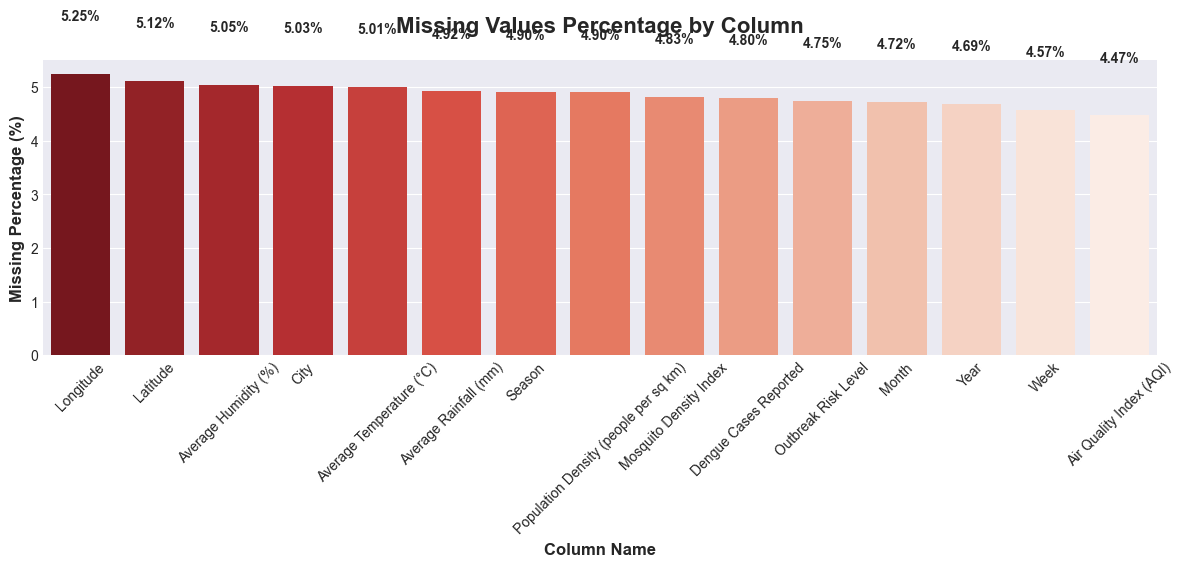

In [8]:
# Visualize missing values
if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sns.barplot(
        data=missing_data, 
        x='Column', 
        y='Missing_Percentage',
        palette='Reds_r',
        ax=ax
    )
    
    ax.set_title('Missing Values Percentage by Column', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Name', fontsize=12, fontweight='bold')
    ax.set_ylabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on bars
    for i, v in enumerate(missing_data['Missing_Percentage']):
        ax.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values to visualize!")

## 5️⃣ Handle Missing Values

In [9]:
# Create a copy of the dataframe
df_clean = df.copy()

print("🔧 Handling Missing Values...\n")

# Strategy:
# 1. Year & Week: Forward fill (ffill) then backward fill (bfill) for time continuity
# 2. Numerical columns: Fill with median (robust to outliers)
# 3. Categorical columns: Fill with mode (most frequent value)

# Handle Year and Week with forward/backward filling first
time_cols = ['Year', 'Week']
for col in time_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        missing_before = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].fillna(method='ffill').fillna(method='bfill')
        missing_after = df_clean[col].isnull().sum()
        print(f"📅 Filled {col} with forward/backward fill: {missing_before} → {missing_after} nulls")

# Identify numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Remove Year and Week from numerical_cols if they exist (already handled)
numerical_cols = [col for col in numerical_cols if col not in time_cols]

print(f"\n📊 Numerical Columns: {len(numerical_cols)}")
print(f"📋 Categorical Columns: {len(categorical_cols)}\n")

# Handle numerical columns
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"✅ Filled {col} with median: {median_value:.2f}")

# Handle categorical columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✅ Filled {col} with mode: {mode_value}")

print(f"\n✅ Missing values handled successfully!")
print(f"Total missing values after cleaning: {df_clean.isnull().sum().sum()}")

🔧 Handling Missing Values...

📅 Filled Year with forward/backward fill: 732 → 0 nulls
📅 Filled Week with forward/backward fill: 713 → 0 nulls

📊 Numerical Columns: 9
📋 Categorical Columns: 4

✅ Filled Average Temperature (°C) with median: 26.75
✅ Filled Average Rainfall (mm) with median: 13.68
✅ Filled Average Humidity (%) with median: 67.53
✅ Filled Air Quality Index (AQI) with median: 113.70
✅ Filled Mosquito Density Index with median: 0.49
✅ Filled Population Density (people per sq km) with median: 8500.00
✅ Filled Dengue Cases Reported with median: 43.00
✅ Filled Latitude with median: 22.31
✅ Filled Longitude with median: 77.71
✅ Filled Month with mode: January
✅ Filled Season with mode: Monsoon
✅ Filled City with mode: Ahmedabad
✅ Filled Outbreak Risk Level with mode: Low

✅ Missing values handled successfully!
Total missing values after cleaning: 0


## 6️⃣ Remove Duplicates

In [10]:
# Remove duplicate rows
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print(f"🔄 Duplicate Removal:")
print(f"   Rows before: {rows_before}")
print(f"   Rows after: {rows_after}")
print(f"   Rows removed: {rows_removed}")

if rows_removed > 0:
    print(f"\n✅ Removed {rows_removed} duplicate rows!")
else:
    print(f"\n✅ No duplicate rows to remove!")

🔄 Duplicate Removal:
   Rows before: 15600
   Rows after: 15600
   Rows removed: 0

✅ No duplicate rows to remove!


## 7️⃣ Data Distribution Analysis

In [11]:
# Check unique values in categorical columns
print("📋 Unique Values in Categorical Columns:")
print("="*60)

for col in categorical_cols:
    unique_count = df_clean[col].nunique()
    print(f"\n{col}: {unique_count} unique values")
    print(f"Values: {df_clean[col].unique()[:10]}...") if unique_count > 10 else print(f"Values: {df_clean[col].unique()}")

📋 Unique Values in Categorical Columns:

Month: 12 unique values
Values: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October']...

Season: 4 unique values
Values: ['Winter' 'Monsoon' 'Summer' 'Post-Monsoon']

City: 30 unique values
Values: ['Delhi (NCT)' 'Mumbai' 'Kolkata' 'Chennai' 'Bengaluru' 'Hyderabad' 'Pune'
 'Ahmedabad' 'Jaipur' 'Lucknow']...

Outbreak Risk Level: 3 unique values
Values: ['Low' 'Moderate' 'High']


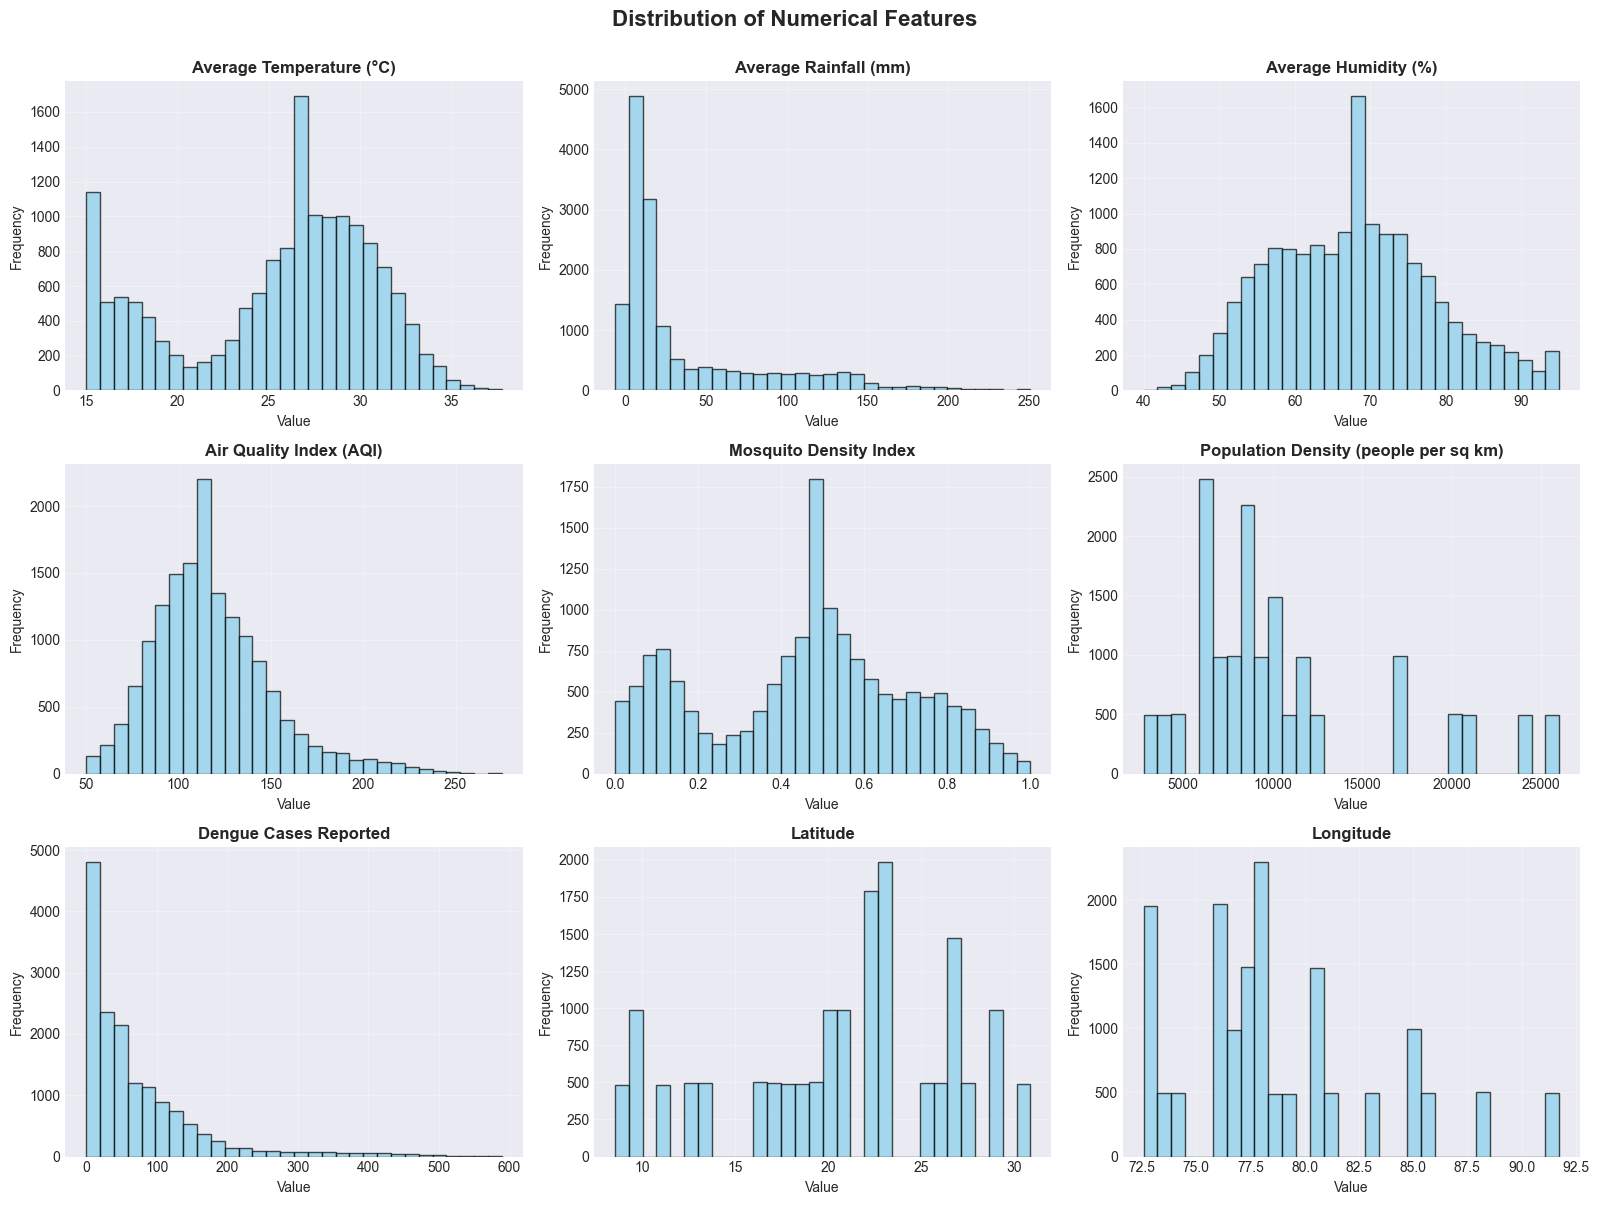

In [12]:
# Visualize distribution of numerical features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols[:9]):
    axes[idx].hist(df_clean[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), 9):
    axes[idx].axis('off')

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8️⃣ Feature Engineering

In [13]:
# Convert Month names to numerical if needed
if 'Month' in df_clean.columns and df_clean['Month'].dtype == 'object':
    month_mapping = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }
    df_clean['Month_Num'] = df_clean['Month'].map(month_mapping)
    print("✅ Created Month_Num feature from Month names")

# Create season feature
if 'Month_Num' in df_clean.columns:
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Summer'
        elif month in [6, 7, 8, 9]:
            return 'Monsoon'
        else:
            return 'Post-Monsoon'
    
    df_clean['Season'] = df_clean['Month_Num'].apply(get_season)
    print("✅ Created Season feature based on months")

print("\n📊 New features created!")
print(f"Total columns now: {df_clean.shape[1]}")

✅ Created Month_Num feature from Month names
✅ Created Season feature based on months

📊 New features created!
Total columns now: 16


## 9️⃣ Encode Categorical Variables

In [14]:
# Create a copy for encoding
df_encoded = df_clean.copy()

# Initialize label encoders dictionary
label_encoders = {}

print("🔧 Encoding Categorical Variables...\n")

# Get categorical columns to encode
cols_to_encode = df_encoded.select_dtypes(include=['object']).columns.tolist()

# Encode each categorical column
for col in cols_to_encode:
    le = LabelEncoder()
    df_encoded[f'{col}_Encoded'] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    
    print(f"✅ Encoded {col}:")
    print(f"   Classes: {list(le.classes_)}")
    print(f"   Encoded values: {list(le.transform(le.classes_))}\n")

print(f"✅ Encoding completed! {len(cols_to_encode)} columns encoded.")

🔧 Encoding Categorical Variables...

✅ Encoded Month:
   Classes: ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']
   Encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

✅ Encoded Season:
   Classes: ['Monsoon', 'Post-Monsoon', 'Summer', 'Winter']
   Encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

✅ Encoded City:
   Classes: ['Agra', 'Ahmedabad', 'Bengaluru', 'Bhopal', 'Bhubaneswar', 'Chennai', 'Coimbatore', 'Delhi (NCT)', 'Guwahati', 'Hyderabad', 'Indore', 'Jaipur', 'Kanpur', 'Kochi (Cochin)', 'Kolkata', 'Lucknow', 'Ludhiana', 'Madurai', 'Meerut', 'Mumbai', 'Nagpur', 'Nashik', 'Patna', 'Pune', 'Ranchi', 'Surat', 'Thiruvananthapuram (Trivandrum)', 'Vadodara (Baroda)', 'Vijayawada', 'Visakhapatnam']
   Encoded values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), 

## 🔟 Correlation Analysis

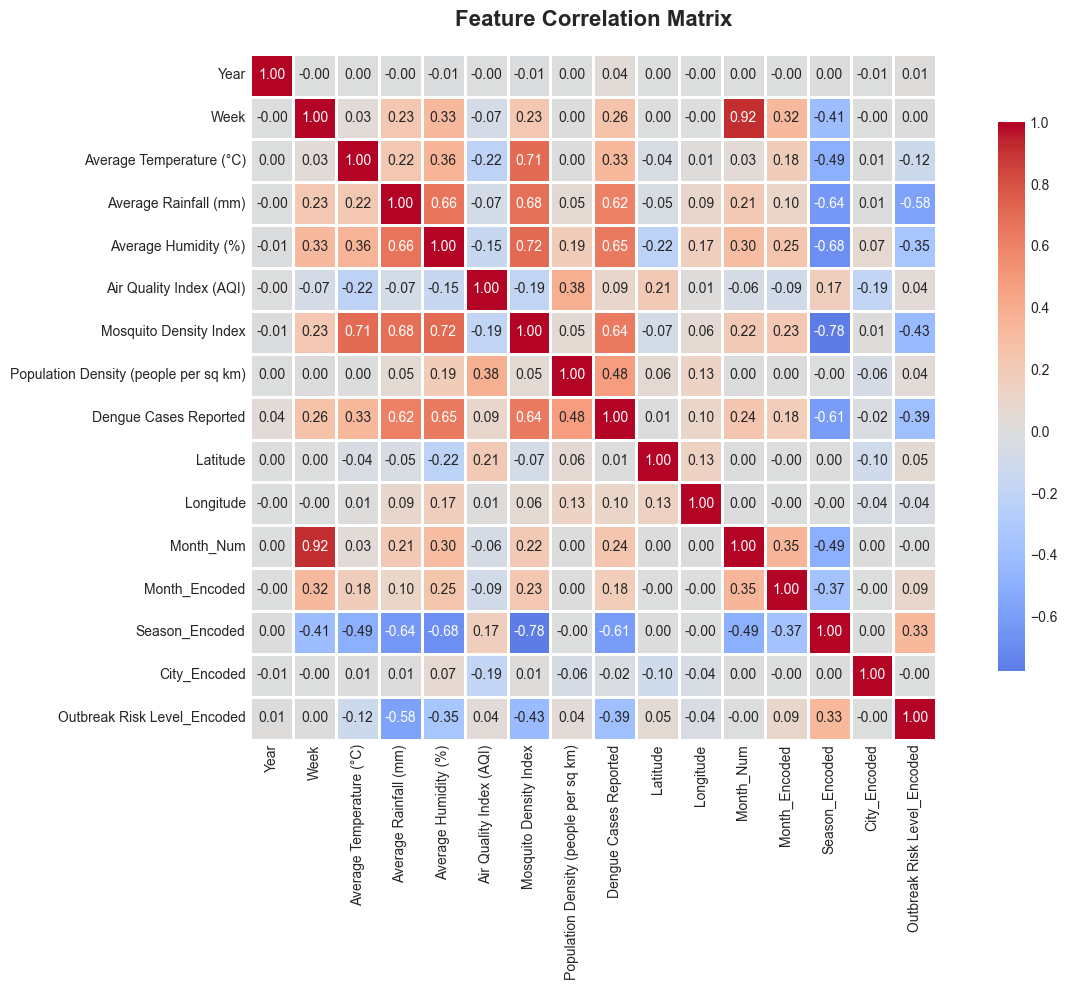


✅ Correlation analysis completed!


In [15]:
# Select only numerical columns for correlation
numerical_df = df_encoded.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✅ Correlation analysis completed!")

## 1️⃣1️⃣ Prepare Features and Target

In [16]:
# Identify target column (adjust based on your dataset)
# Common target names: 'Outbreak Risk Level', 'Risk_Level', 'Target', etc.

target_candidates = ['Outbreak Risk Level', 'Risk_Level', 'Outbreak_Risk_Level', 'Target']
target_col = None

for col in target_candidates:
    if col in df_encoded.columns:
        target_col = col
        break

if target_col:
    print(f"🎯 Target Column: {target_col}")
    print(f"   Unique values: {df_encoded[target_col].unique()}")
    print(f"\n   Distribution:")
    print(df_encoded[target_col].value_counts())
else:
    print("⚠️  Target column not found. Please specify the target column manually.")
    print(f"Available columns: {df_encoded.columns.tolist()}")

🎯 Target Column: Outbreak Risk Level
   Unique values: ['Low' 'Moderate' 'High']

   Distribution:
Outbreak Risk Level
Low         8143
High        4327
Moderate    3130
Name: count, dtype: int64


In [17]:
# Select features (exclude original categorical columns and target)
# Adjust this based on your dataset structure

# Columns to exclude from features
exclude_cols = cols_to_encode.copy()  # Original categorical columns
if target_col:
    exclude_cols.append(target_col)

# Select feature columns
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

print(f"📊 Feature Columns ({len(feature_cols)}):")
print(feature_cols)

# Prepare X (features) and y (target)
if target_col:
    X = df_encoded[feature_cols]
    
    # If target is categorical, encode it
    if df_encoded[target_col].dtype == 'object':
        y = LabelEncoder().fit_transform(df_encoded[target_col])
        print(f"\n✅ Target encoded: {df_encoded[target_col].unique()} → {np.unique(y)}")
    else:
        y = df_encoded[target_col]
    
    print(f"\n✅ Features (X): {X.shape}")
    print(f"✅ Target (y): {y.shape}")
else:
    print("⚠️  Cannot prepare X and y without target column.")

📊 Feature Columns (16):
['Year', 'Week', 'Average Temperature (°C)', 'Average Rainfall (mm)', 'Average Humidity (%)', 'Air Quality Index (AQI)', 'Mosquito Density Index', 'Population Density (people per sq km)', 'Dengue Cases Reported', 'Latitude', 'Longitude', 'Month_Num', 'Month_Encoded', 'Season_Encoded', 'City_Encoded', 'Outbreak Risk Level_Encoded']

✅ Target encoded: ['Low' 'Moderate' 'High'] → [0 1 2]

✅ Features (X): (15600, 16)
✅ Target (y): (15600,)


## 1️⃣2️⃣ Feature Scaling

In [18]:
# Apply StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("⚖️  Feature Scaling Applied (StandardScaler)")
print(f"\n   Original data range:")
print(X.describe().loc[['min', 'max']])
print(f"\n   Scaled data range:")
print(X_scaled_df.describe().loc[['min', 'max']])

print("\n✅ Scaling completed!")

⚖️  Feature Scaling Applied (StandardScaler)

   Original data range:
       Year  Week  Average Temperature (°C)  Average Rainfall (mm)  \
min  2015.0   1.0                     15.00                  -6.34   
max  2024.0  52.0                     37.77                 250.99   

     Average Humidity (%)  Air Quality Index (AQI)  Mosquito Density Index  \
min                  40.0                     50.0                     0.0   
max                  95.0                    275.0                     1.0   

     Population Density (people per sq km)  Dengue Cases Reported  Latitude  \
min                                 2800.0                    0.0    8.5241   
max                                26000.0                  589.0   30.9010   

     Longitude  Month_Num  Month_Encoded  Season_Encoded  City_Encoded  \
min    72.5714        1.0            0.0             0.0           0.0   
max    91.7362       12.0           11.0             3.0          29.0   

     Outbreak Risk Leve

## 1️⃣3️⃣ Train-Test Split

In [19]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

print("✂️  Train-Test Split (80-20):")
print("="*60)
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:    {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")

print(f"\n📊 Class Distribution in Training Set:")
print(pd.Series(y_train).value_counts())

print(f"\n📊 Class Distribution in Testing Set:")
print(pd.Series(y_test).value_counts())

print("\n✅ Data split completed!")

✂️  Train-Test Split (80-20):
Training set:   12480 samples (80.0%)
Testing set:    3120 samples (20.0%)

Features: 16

📊 Class Distribution in Training Set:
1    6514
0    3462
2    2504
Name: count, dtype: int64

📊 Class Distribution in Testing Set:
1    1629
0     865
2     626
Name: count, dtype: int64

✅ Data split completed!


## 1️⃣4️⃣ Save Processed Data

In [20]:
# Save cleaned data
df_clean.to_csv('dengue_data_cleaned.csv', index=False)
print("✅ Saved: dengue_data_cleaned.csv")

# Save encoded data
df_encoded.to_csv('dengue_data_encoded.csv', index=False)
print("✅ Saved: dengue_data_encoded.csv")

# Save train-test split data
pd.DataFrame(X_train).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)
pd.DataFrame(y_train, columns=['target']).to_csv('y_train.csv', index=False)
pd.DataFrame(y_test, columns=['target']).to_csv('y_test.csv', index=False)

print("✅ Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")

print("\n🎉 All processed data saved successfully!")

✅ Saved: dengue_data_cleaned.csv

✅ Saved: dengue_data_encoded.csv
✅ Saved: dengue_data_encoded.csv
✅ Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv

🎉 All processed data saved successfully!
✅ Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv

🎉 All processed data saved successfully!


## 1️⃣5️⃣ Summary Report

In [21]:
print("="*70)
print("📋 DATA PREPROCESSING SUMMARY REPORT")
print("="*70)

print(f"\n✅ DATASET OVERVIEW:")
print(f"   Original shape: {df.shape}")
print(f"   Cleaned shape: {df_clean.shape}")
print(f"   Final shape: {df_encoded.shape}")

print(f"\n✅ DATA QUALITY:")
print(f"   Missing values handled: {df.isnull().sum().sum()} → {df_clean.isnull().sum().sum()}")
print(f"   Duplicates removed: {rows_removed}")

print(f"\n✅ FEATURE ENGINEERING:")
print(f"   Original columns: {df.shape[1]}")
print(f"   Final columns: {df_encoded.shape[1]}")
print(f"   Categorical columns encoded: {len(cols_to_encode)}")

print(f"\n✅ MODEL PREPARATION:")
print(f"   Feature columns: {len(feature_cols)}")
print(f"   Training samples: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Testing samples: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n✅ OUTPUT FILES:")
print(f"   1. dengue_data_cleaned.csv")
print(f"   2. dengue_data_encoded.csv")
print(f"   3. X_train.csv, X_test.csv")
print(f"   4. y_train.csv, y_test.csv")

print("\n" + "="*70)
print("🎉 DATA PREPROCESSING COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📝 Next Steps:")
print("   1. Proceed to Model Training notebook")
print("   2. Try different ML algorithms")
print("   3. Perform hyperparameter tuning")
print("   4. Evaluate model performance")

📋 DATA PREPROCESSING SUMMARY REPORT

✅ DATASET OVERVIEW:
   Original shape: (15600, 15)
   Cleaned shape: (15600, 16)
   Final shape: (15600, 20)

✅ DATA QUALITY:
   Missing values handled: 11394 → 0
   Duplicates removed: 0

✅ FEATURE ENGINEERING:
   Original columns: 15
   Final columns: 20
   Categorical columns encoded: 4

✅ MODEL PREPARATION:
   Feature columns: 16
   Training samples: 12480 (80.0%)
   Testing samples: 3120 (20.0%)

✅ OUTPUT FILES:
   1. dengue_data_cleaned.csv
   2. dengue_data_encoded.csv
   3. X_train.csv, X_test.csv
   4. y_train.csv, y_test.csv

🎉 DATA PREPROCESSING COMPLETED SUCCESSFULLY!

📝 Next Steps:
   1. Proceed to Model Training notebook
   2. Try different ML algorithms
   3. Perform hyperparameter tuning
   4. Evaluate model performance
